# Predicting wine quality with binary classification

In [217]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### importing the data

In [218]:
redwine_df = pd.read_csv('../winequality-red-clean.csv', sep=',')
redwine_df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
369,9.5,0.56,0.33,2.4,0.089,35.0,67.0,0.99720,3.28,0.73,11.8,7
489,10.6,0.31,0.49,2.5,0.067,6.0,21.0,0.99870,3.26,0.86,10.7,6
1260,8.0,0.64,0.22,2.4,0.094,5.0,33.0,0.99612,3.37,0.58,11.0,5
272,9.0,0.46,0.31,2.8,0.093,19.0,98.0,0.99815,3.32,0.63,9.5,6
839,7.4,0.61,0.01,2.0,0.074,13.0,38.0,0.99748,3.48,0.65,9.8,5


### inspecting the dataset , datatypes and names of the columns

In [219]:
redwine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1458 non-null   float64
 1   volatile acidity      1458 non-null   float64
 2   citric acid           1458 non-null   float64
 3   residual sugar        1458 non-null   float64
 4   chlorides             1458 non-null   float64
 5   free sulfur dioxide   1458 non-null   float64
 6   total sulfur dioxide  1458 non-null   float64
 7   density               1458 non-null   float64
 8   pH                    1458 non-null   float64
 9   sulphates             1458 non-null   float64
 10  alcohol               1458 non-null   float64
 11  quality               1458 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 136.8 KB


### Simple Descriptive Analysis

In [220]:
redwine_df.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1458.000000,8.312209,1.647586,5.000000,7.100000,7.900000,9.200000,13.500000
volatile acidity,1458.000000,0.524155,0.169595,0.120000,0.390000,0.520000,0.635000,1.040000
citric acid,1458.000000,0.265281,0.191271,0.000000,0.090000,0.250000,0.420000,0.790000
residual sugar,1458.000000,2.388717,0.865307,1.200000,1.900000,2.200000,2.600000,6.700000
chlorides,1458.000000,0.081580,0.021298,0.038000,0.070000,0.079000,0.089000,0.226000
free sulfur dioxide,1458.000000,15.089849,9.317669,1.000000,7.000000,13.000000,21.000000,47.000000
total sulfur dioxide,1458.000000,43.662209,29.414125,6.000000,21.000000,36.000000,58.000000,145.000000
density,1458.000000,0.996718,0.001718,0.991500,0.995600,0.996700,0.997800,1.002200
pH,1458.000000,3.316276,0.141196,2.880000,3.220000,3.315000,3.400000,3.750000
sulphates,1458.000000,0.642414,0.129753,0.330000,0.550000,0.620000,0.720000,1.160000


### the scater plot describes the relationship between the density and alcohol content of the red wine.
##### the data shows that the density of the red wine is inversely proportional to the alcohol content. The higher the alcohol content, the lower the density of the red wine.

<Axes: xlabel='density', ylabel='alcohol'>

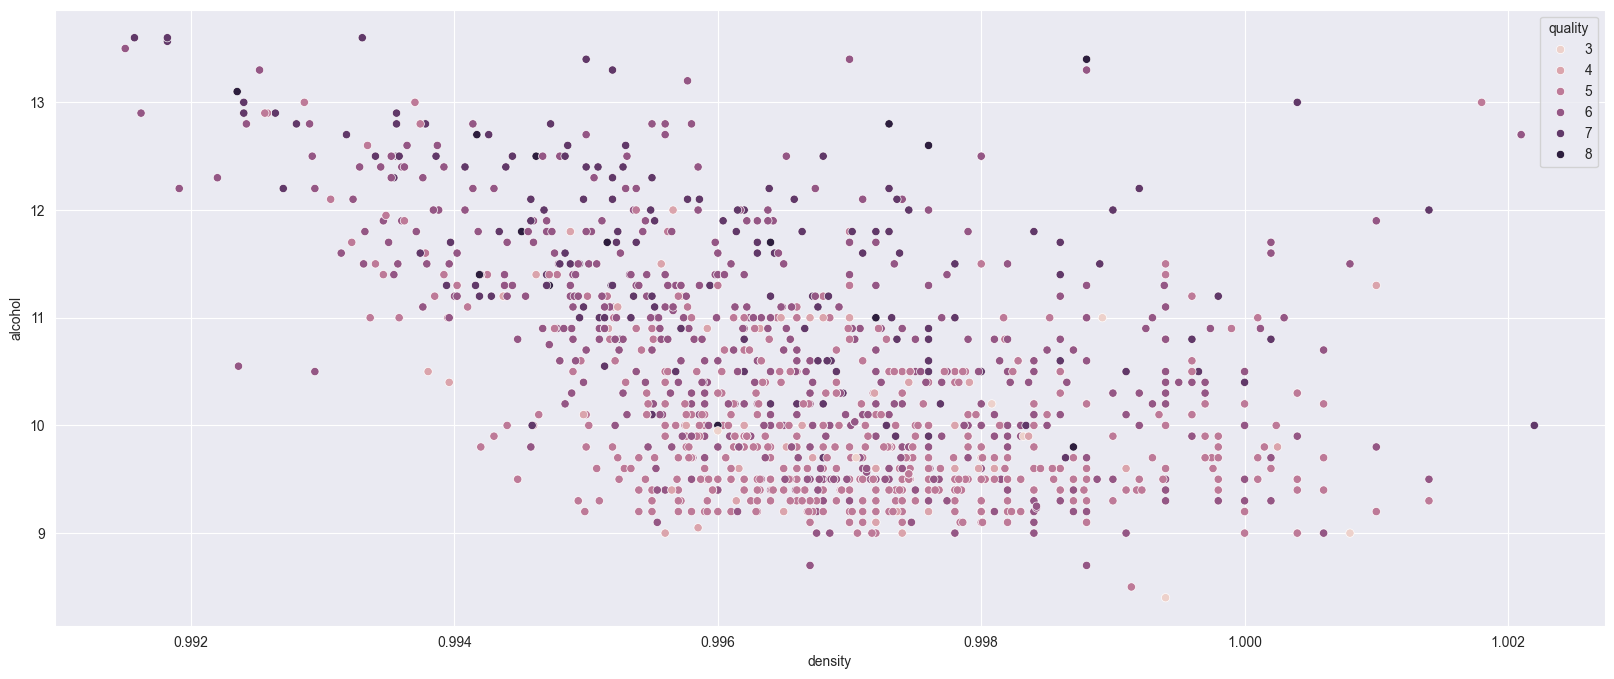

In [221]:
plt.figure(figsize=(20, 8))
sns.scatterplot(x='density', y='alcohol', data= redwine_df, hue='quality')

# Interesting Correlations:

Fixed acidity and pH have a strong negative correlation (-0.68), meaning that as fixed acidity increases, pH decreases.

Alcohol and quality have a moderately positive correlation (0.48), suggesting that higher alcohol content is associated with better quality.

Free sulfur dioxide and total sulfur dioxide have a high positive correlation (0.67), which makes sense since they are related chemically.

Low or Negligible Correlations: Some variables, like chlorides and citric acid, show almost no correlation (0.056), meaning they don’t have a significant linear relationship.

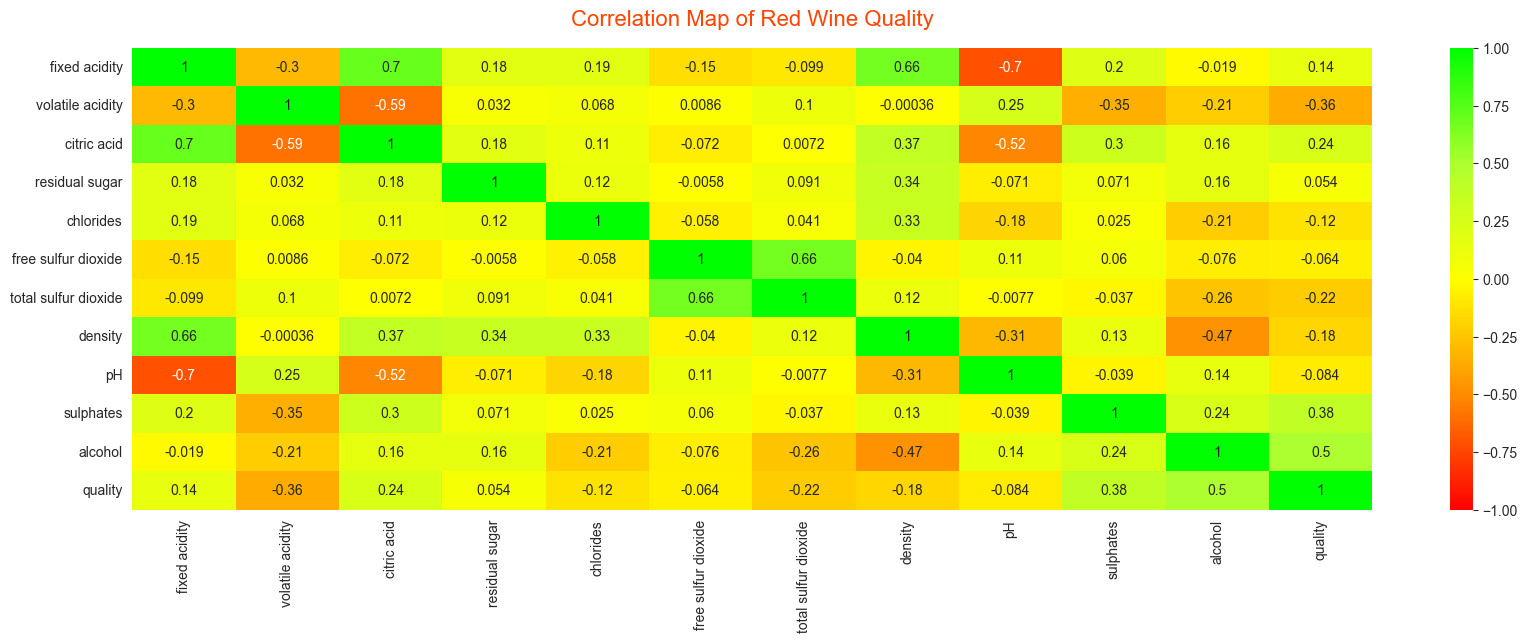

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define a bright and vivid color palette
bright_vivid_palette = mcolors.LinearSegmentedColormap.from_list(
    "bright_vivid_colors", ["#FF0000", "#FF8C00", "#FFFF00", "#ADFF2F", "#00FF00"])

plt.figure(figsize=(20, 6))

# Use the bright and vivid color palette in the heatmap
sns.heatmap(redwine_df.corr(), vmin=-1, vmax=1, annot=True, cmap=bright_vivid_palette, annot_kws={"size": 10})

# Set title with font and color
plt.title('Correlation Map of Red Wine Quality', fontdict={'fontsize': 16, 'color': '#FF4500'}, pad=16)

plt.show()


# PreProcessing

In [223]:
redwine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

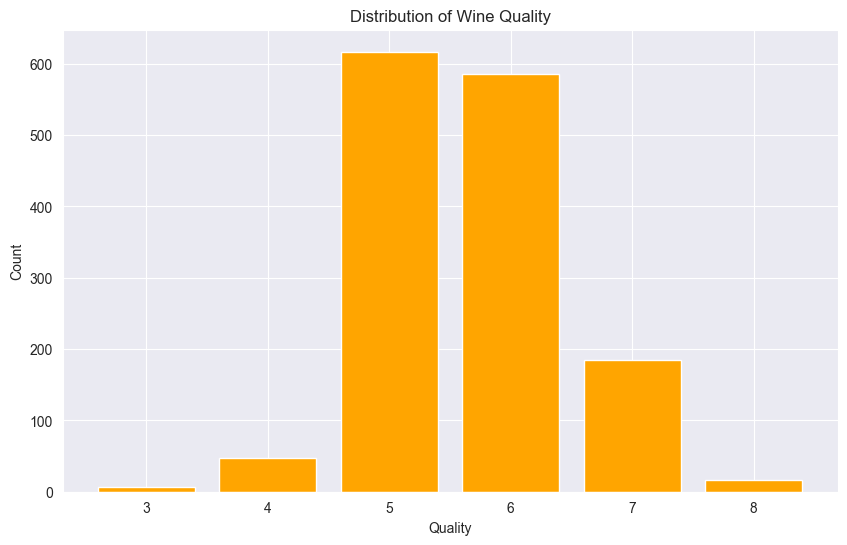

In [224]:
import pandas as pd
import matplotlib.pyplot as plt

quality_counts = redwine_df['quality'].value_counts().sort_index()

quality_df = pd.DataFrame({'quality': quality_counts.index, 'count': quality_counts.values})

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(quality_df['quality'], quality_df['count'], color='orange')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality')
plt.xticks(quality_df['quality'])  # Ensure the x-axis labels match the quality values
plt.show()

- *If the **quality value >= 6**, it means the quality is **good** and I define it as **1**.*
- *If the **quality value < 6,** it means the quality is **bad** and I define it as **0**.*

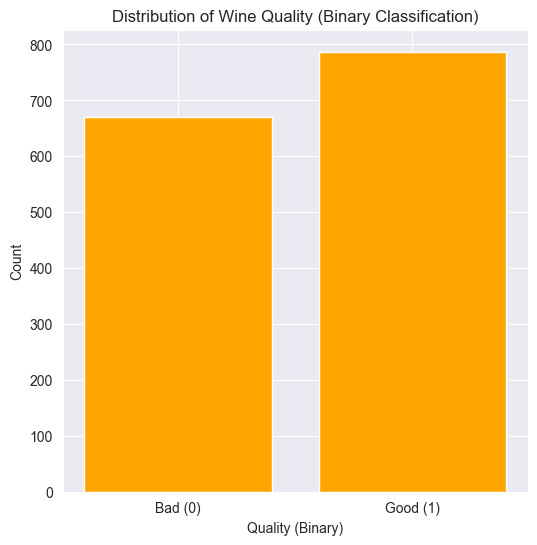

In [225]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create the 'quality_binary' column
redwine_df['quality_binary'] = redwine_df['quality'].apply(lambda x: 0 if x in [3, 4, 5] else 1)

# Step 2: Calculate the value counts for the 'quality_binary' column
quality_binary_counts = redwine_df['quality_binary'].value_counts().sort_index()

# Step 3: Create a DataFrame from the binary counts
binary_df = pd.DataFrame({'quality_binary': quality_binary_counts.index, 'count': quality_binary_counts.values})

# Step 4: Plot the bar chart for quality binary (0 = Bad, 1 = Good)
plt.figure(figsize=(6, 6))
plt.bar(binary_df['quality_binary'], binary_df['count'], color='orange')

# Set custom labels for the binary classification
plt.xticks(binary_df['quality_binary'], labels=['Bad (0)', 'Good (1)'])
plt.xlabel('Quality (Binary)')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality (Binary Classification)')

plt.show()


In [226]:
# Drop the original 'quality' column (if it's still in the DataFrame)
redwine_df = redwine_df.drop(columns=['quality'], errors='ignore')
# rename the new quality column
redwine_df = redwine_df.rename(columns={'quality_binary': 'quality'})
# Display a sample of 10 rows
redwine_df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,36.5,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,1
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,1
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,0


<Figure size 1400x1000 with 0 Axes>

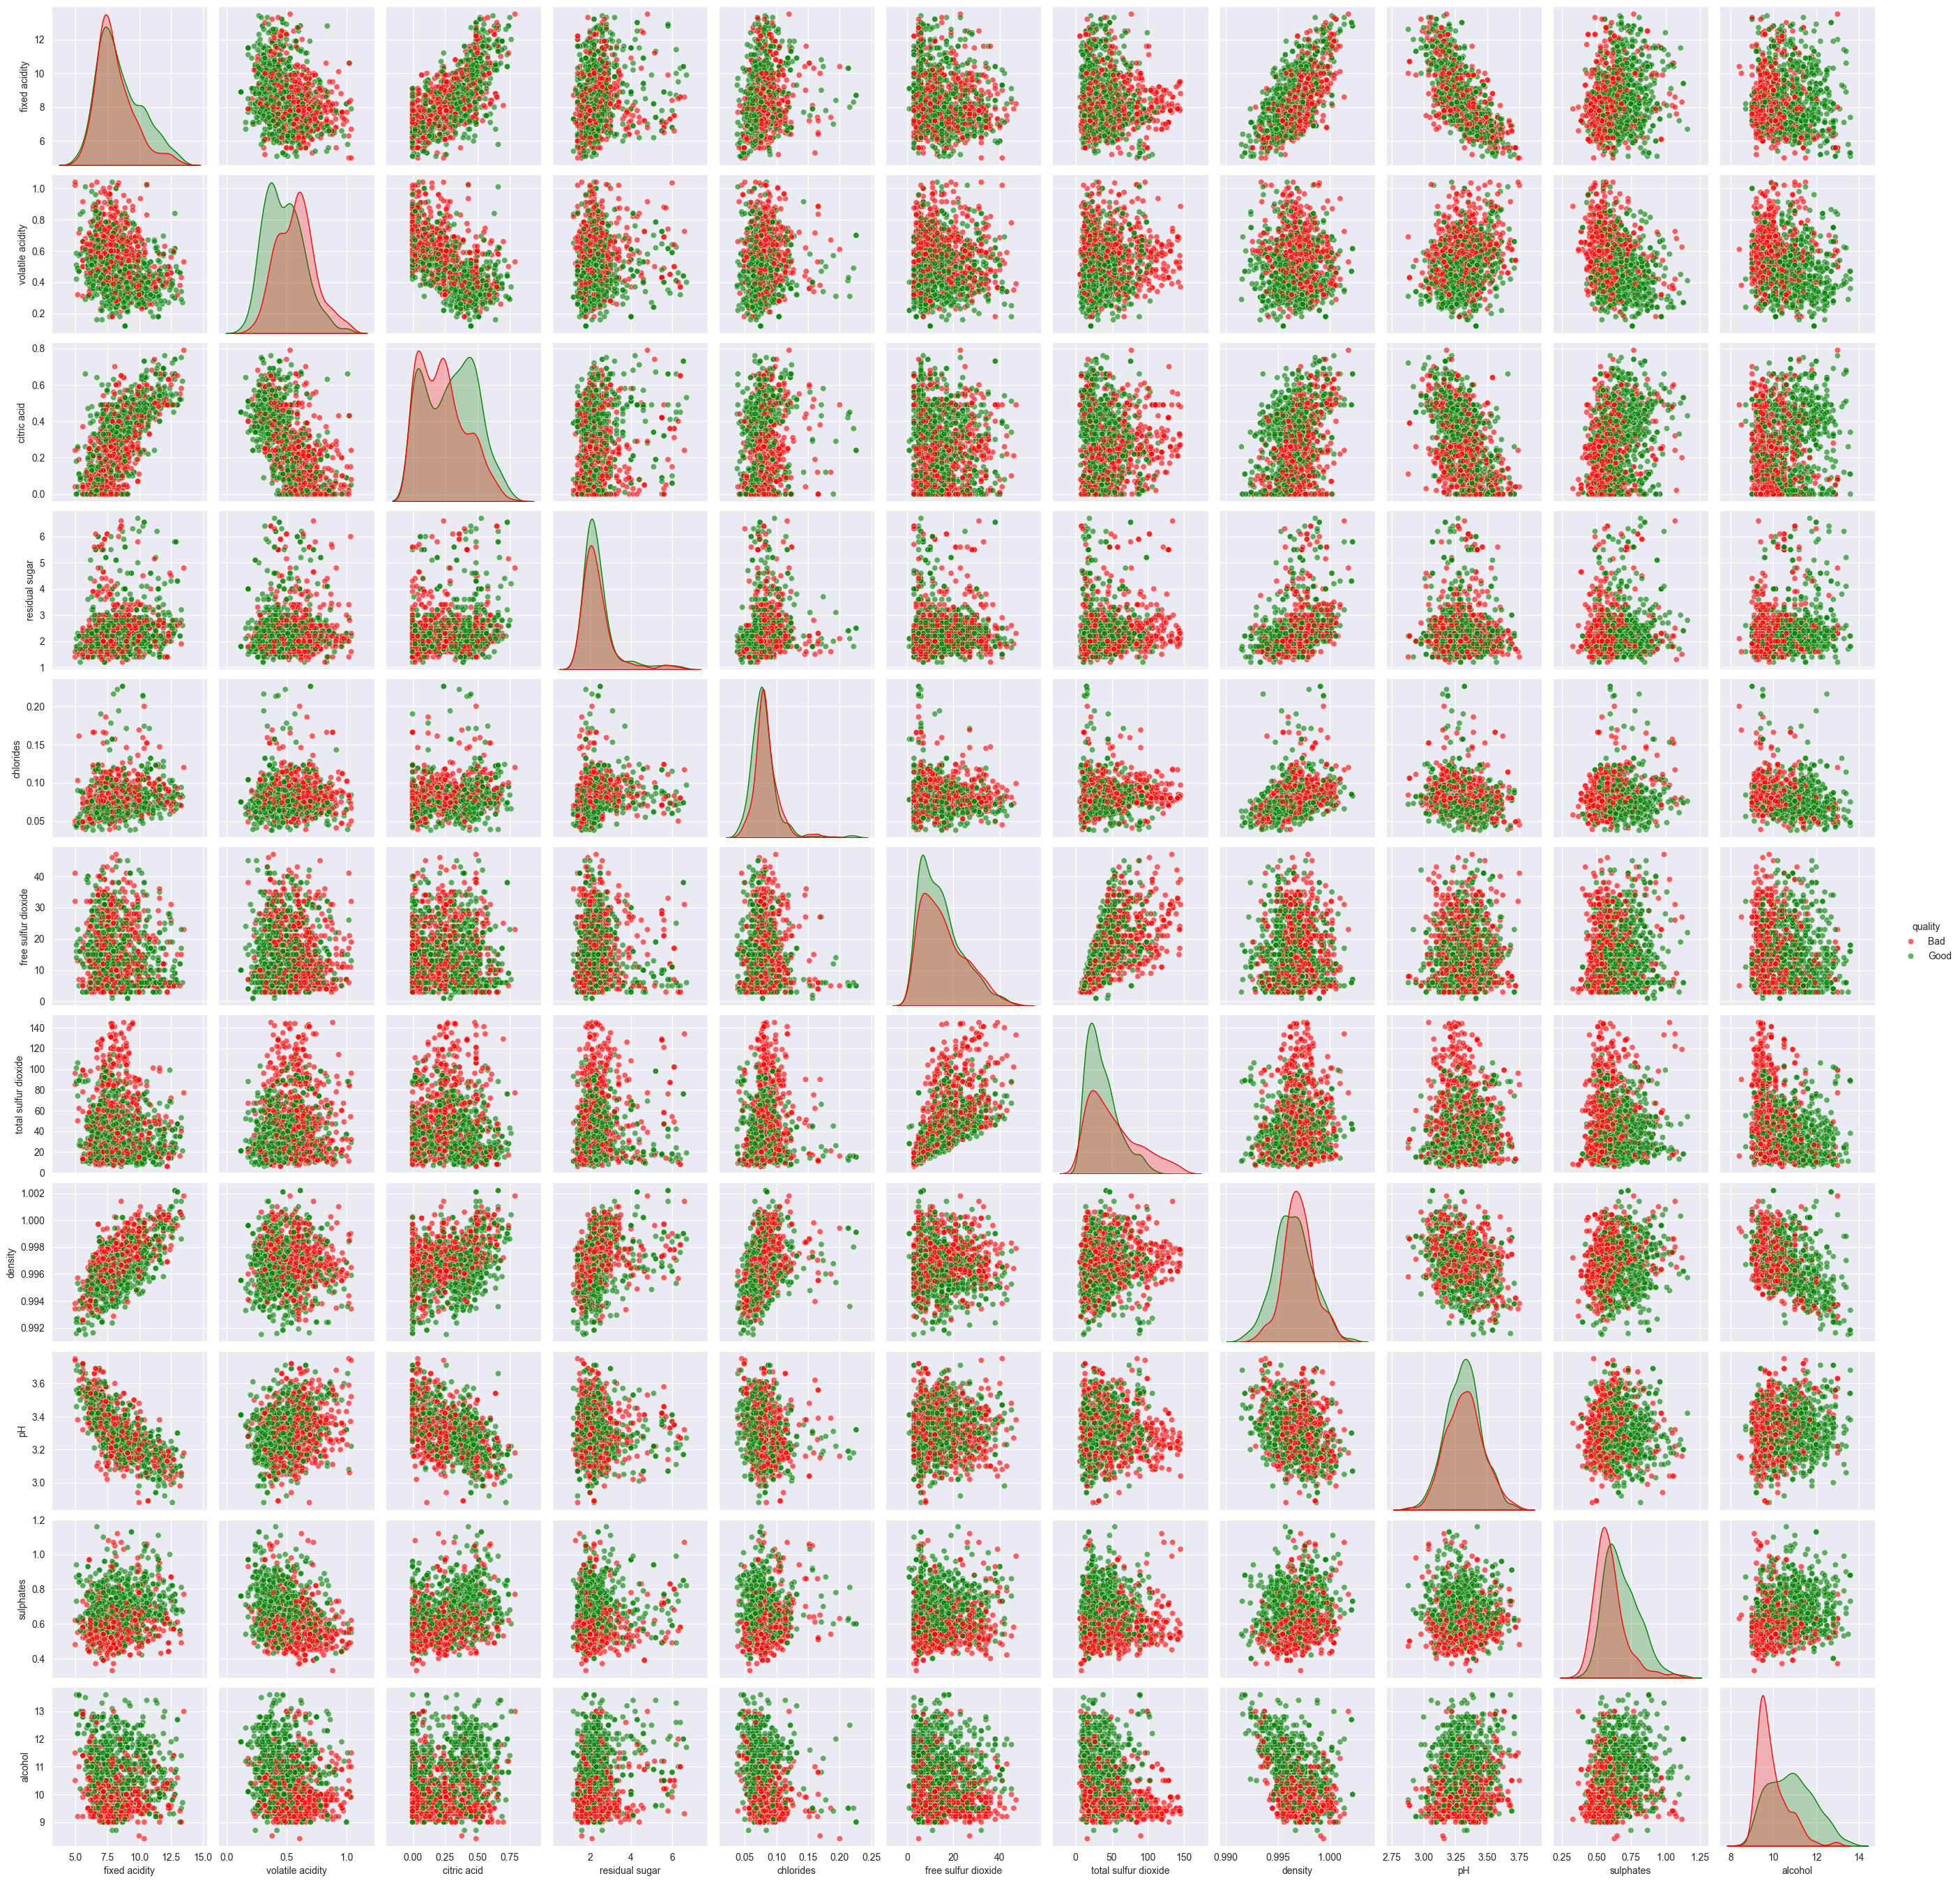

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'redwine_df' is your DataFrame with a 'quality' binary column

# Map the 'quality' column to a categorical feature for color differentiation
redwine_df['quality'] = redwine_df['quality'].map({0: 'Bad', 1: 'Good'})

# Create a pair plot
plt.figure(figsize=(14, 10))
sns.pairplot(redwine_df, hue='quality', palette={'Bad': 'red', 'Good': 'green'}, plot_kws={'alpha':0.6})

# Show the plot
plt.show()


## Find Best K-Score

#### steps
#### 1- splitting the data to train and test
#### 2- finding the best K value. (K value is a value that represents the number of neighbours that the algorithm can take in to account in order to classify )


In [228]:
X = redwine_df.drop(['quality'], axis = 1)
y = redwine_df['quality']

# Find best K
#### this method is going to identify which K score is the best score for my dataset based on train test splitting of the data.

K = 3: Training Accuracy = 0.8645, Testing Accuracy = 0.7363, Overfitting Score = 0.1282
K = 4: Training Accuracy = 0.8148, Testing Accuracy = 0.7158, Overfitting Score = 0.0990
K = 5: Training Accuracy = 0.8062, Testing Accuracy = 0.7466, Overfitting Score = 0.0596
K = 6: Training Accuracy = 0.7890, Testing Accuracy = 0.7260, Overfitting Score = 0.0630
K = 7: Training Accuracy = 0.7882, Testing Accuracy = 0.7500, Overfitting Score = 0.0382
K = 8: Training Accuracy = 0.7770, Testing Accuracy = 0.7397, Overfitting Score = 0.0373
K = 9: Training Accuracy = 0.7744, Testing Accuracy = 0.7432, Overfitting Score = 0.0313
K = 10: Training Accuracy = 0.7736, Testing Accuracy = 0.7740, Overfitting Score = -0.0004
K = 11: Training Accuracy = 0.7702, Testing Accuracy = 0.7671, Overfitting Score = 0.0030
K = 12: Training Accuracy = 0.7710, Testing Accuracy = 0.7500, Overfitting Score = 0.0210
K = 13: Training Accuracy = 0.7599, Testing Accuracy = 0.7397, Overfitting Score = 0.0201
K = 14: Training

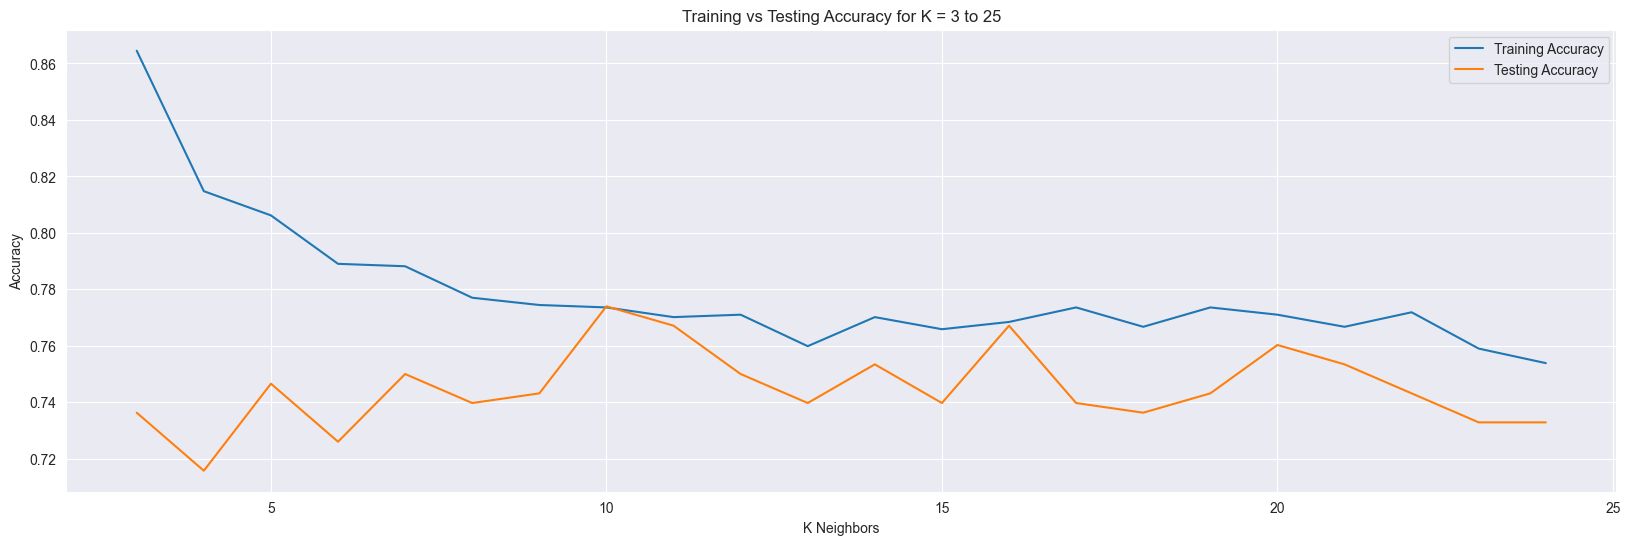

In [229]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Assuming X and y are defined and represent your dataset features and labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Function to find the best K and perform overfitting analysis
def find_best_k(X_train, y_train, X_test, y_test, k_range):
    training_accuracy = []
    testing_accuracy = []
    overfitting_scores = []  # To store the overfitting scores for each K
    best_k = 0
    best_score = 0
    
    k_values = np.arange(k_range[0], k_range[1], k_range[2])

    # Loop over the different K values
    for k in k_values:
        # Define the KNN model with current K value
        knn = KNeighborsClassifier(n_neighbors=k)
        # Create a pipeline with StandardScaler and KNN
        pipeline = Pipeline([('scaler', StandardScaler()), ('knn', knn)])
        
        # Train the model on the training data
        pipeline.fit(X_train, y_train)
        
        # Evaluate on training data
        train_accuracy = pipeline.score(X_train, y_train)
        training_accuracy.append(train_accuracy)
        
        # Evaluate on test data
        test_accuracy = pipeline.score(X_test, y_test)
        testing_accuracy.append(test_accuracy)
        
        # Calculate overfitting score
        overfitting_score = train_accuracy - test_accuracy
        overfitting_scores.append(overfitting_score)
        
        # Print the k value, corresponding accuracies, and overfitting score
        print(f"K = {k}: Training Accuracy = {train_accuracy:.4f}, Testing Accuracy = {test_accuracy:.4f}, Overfitting Score = {overfitting_score:.4f}")
        
        # Check if the test accuracy is the best
        if test_accuracy > best_score:
            best_k = k
            best_score = test_accuracy
    
    # Analysis for overfitting or underfitting
    for idx, k in enumerate(k_values):
        if overfitting_scores[idx] > 0.05:  # Threshold for overfitting
            print(f"At K={k}, the model might be overfitting (Overfitting Score: {overfitting_scores[idx]:.4f}).")
        elif overfitting_scores[idx] < -0.05:  # Significant negative score indicating possible underfitting
            print(f"At K={k}, the model might be underfitting (Overfitting Score: {overfitting_scores[idx]:.4f}).")
        else:
            print(f"At K={k}, no significant overfitting or underfitting detected (Overfitting Score: {overfitting_scores[idx]:.4f}).")
    
    return best_k, best_score, training_accuracy, testing_accuracy, k_values

# Find the best K for k_range (3, 25)
best_k, best_score, training_accuracy, testing_accuracy, k_values = find_best_k(X_train, y_train, X_test, y_test, k_range=(3, 25, 1))

# Print the best K and the best score
print(f"\nBest K for range 3-25: {best_k}")
print(f"Best Testing Accuracy for range 3-25: {best_score:.4f}")

# Plot for K range 3-25
plt.figure(figsize=(20, 6))
sns.lineplot(x=k_values, y=training_accuracy, label="Training Accuracy")
sns.lineplot(x=k_values, y=testing_accuracy, label="Testing Accuracy")
plt.title("Training vs Testing Accuracy for K = 3 to 25")
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


For \( K = 10 \):
- **Training Accuracy**: 0.7736
- **Testing Accuracy**: 0.7740
- **Overfitting Score**: -0.0004

### Analysis:
1. **Overfitting Score**: The score is **very close to zero** (-0.0004), indicating no significant gap between training and testing accuracies.
2. **Training and Testing Accuracy**: Both accuracies are reasonably high and nearly identical, suggesting the model generalizes well to unseen data.

### Conclusion:
- This model with \( K = 10 \) is **balanced** and exhibits **no significant overfitting or underfitting**.
- The close alignment of training and testing accuracy implies the model is well-suited to the data, making \( K = 10 \) an excellent choice for this scenario.


## K-Nearest Neighbors (KNN) Training vs Testing Accuracy for Different Values of K

1. **Training Accuracy (Blue Line)**:
    - Initially, the training accuracy is very high for low K values, suggesting potential overfitting.
    - As K increases, the training accuracy decreases, indicating that the model becomes less specific to the training data.
    - The training accuracy stabilizes around K = 9, reaching a plateau.

2. **Testing Accuracy (Orange Line)**:
    - Testing accuracy starts low but increases as K increases.
    - The highest test accuracy is observed around K = 9, indicating that this value of K generalizes best to unseen data.
    - Beyond K = 9, the testing accuracy decreases or remains stable, suggesting that larger K values may underfit the data.

3. **Best K Value**:
    - The best value of K is 9, as indicated at the top of the graph, with a test accuracy of approximately 0.7551.

### Conclusion:
- A K value of 9 seems to provide the optimal balance between high training accuracy and improved generalization to the test set.
- Lower K values lead to overfitting (high training accuracy but low testing accuracy), while higher K values result in underfitting (both accuracies decrease).


In [230]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler  # Changed to StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# making the model with 9 neighbors 
knn = KNeighborsClassifier(n_neighbors=10)

# creating a pipeline
pipe_knn = Pipeline([('scale', StandardScaler()), ('knn', knn)])

# Fit the model to the training data
pipe_knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipe_knn.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with K=9 and Ball Tree: {accuracy:.4f}")

# Display detailed performance metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy with K=9 and Ball Tree: 0.7740
Classification Report:
              precision    recall  f1-score   support

         Bad       0.72      0.76      0.74       123
        Good       0.82      0.79      0.80       169

    accuracy                           0.77       292
   macro avg       0.77      0.77      0.77       292
weighted avg       0.78      0.77      0.77       292



# HyperParameter Tuning

In [231]:
from pprint import pprint
pprint(pipe_knn.get_params(), indent=4)

{   'knn': KNeighborsClassifier(n_neighbors=10),
    'knn__algorithm': 'auto',
    'knn__leaf_size': 30,
    'knn__metric': 'minkowski',
    'knn__metric_params': None,
    'knn__n_jobs': None,
    'knn__n_neighbors': 10,
    'knn__p': 2,
    'knn__weights': 'uniform',
    'memory': None,
    'scale': StandardScaler(),
    'scale__copy': True,
    'scale__with_mean': True,
    'scale__with_std': True,
    'steps': [   ('scale', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=10))],
    'verbose': False}


In [232]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


knn = KNeighborsClassifier()
pipe_knn = Pipeline([('scaler', StandardScaler()), ('knn', knn)])


param_grid = {
    'knn__n_neighbors': [6, 8, 10, 12, 14, 16, 18],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['manhattan', 'euclidean'],
    'knn__algorithm': ['ball_tree', 'kd_tree', 'brute'] 
}


grid_search = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fitting the grid search on the training data
grid_search.fit(X_train, y_train)

# getting the best parameters and scores
print("Best hyperparameters found: ", grid_search.best_params_)
best_score = grid_search.best_score_
print(f"Best accuracy score from GridSearchCV: {best_score:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Test Accuracy after Hyperparameter Tuning: {accuracy_score(y_test, y_pred_best):.4f}")
print("Classification Report for Best Model:")
print(classification_report(y_test, y_pred_best))


Best hyperparameters found:  {'knn__algorithm': 'ball_tree', 'knn__metric': 'manhattan', 'knn__n_neighbors': 16, 'knn__weights': 'distance'}
Best accuracy score from GridSearchCV: 0.8002
Test Accuracy after Hyperparameter Tuning: 0.8185
Classification Report for Best Model:
              precision    recall  f1-score   support

         Bad       0.78      0.79      0.79       123
        Good       0.85      0.84      0.84       169

    accuracy                           0.82       292
   macro avg       0.81      0.81      0.81       292
weighted avg       0.82      0.82      0.82       292

